# Proof of concept: Adding Spatial Wavelet Decomposition and Reconstruction to Chromatin Deconvolution
February 16, 2024

We've shown that it is possible to decompose a 2D image into wavelet coefficients and reconstruct within cvxpy. The next step is the feasibility with doing a large set of image coefficients and with the chromatin deconvolution. We had previously deconvolved the coefficients of the images, but were unable to enforce valid non-negative coefficients that produce images. So, this may be a chance to find a place where we can enforce valid non-negative f images, because we are now able to reconstruct the images from coefficients within cvxpy to enforce constraints or norms on the minimization function. We will also be checking feasibility and timing of introducing these additional wavelet computations.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
import numpy as np
import pywt

In [3]:
# let's start with a 16x16 of a chromatin image

from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config

config = load_yl_replicate1_rg1_alpha_vst_config()
chromatin_model = ChromatinModel(config)
chromatin_model.load_mnase_gene('CLB2', replicate=1)

Loading MNase reads for CLB2...Done.


In [4]:
from src.chromatin_wavelets import ChromatinWavelets

chrom_wavelets = ChromatinWavelets(chromatin_model)
chrom_wavelets.create_coefficients()

The shape of G is:  (16, 256)
The shape of G images is:  (16, 8, 32)
Created coefficients matrix of shape: (16, 4, 4, 16)
Created coefficients vectorized matrix of shape: (16, 256)


In [5]:
G = chrom_wavelets.G

In [6]:
chromatin_model.setup_deconv_model()

In [7]:
from src.deconvolve_chromatin import deconvolve_chromatin_H

deconv_model = chromatin_model.deconv_model
deconv_model.gamma = 0.001
H = deconv_model.H

In [8]:
image_shape = chrom_wavelets.image_shape

In [9]:
coeffs_shape = chrom_wavelets.coeffs_shape
coeffs_shape

(4, 16)

In [77]:
from src.deconvolve_wavelet_chromatin import deconvolve_wavelet_chromatin

f, rn, sn = deconvolve_wavelet_chromatin(deconv_model, H, G, coeffs_shape,
     verbose=True, image_shape=image_shape)


                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Feb 17 02:17:04 PM: Your problem has 58112 variables, 1 constraints, and 0 parameters.
(CVXPY) Feb 17 02:17:04 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 17 02:17:04 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 17 02:17:04 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 17 02:17:04 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 17 02:17:04 PM: Compiling problem (target solver=MOSEK).


/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/cvxpy/problems/problem.py:158: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn("Objective contains too many subexpressions. "


(CVXPY) Feb 17 02:17:05 PM: Applying reduction CvxAttr2Constr
(CVXPY) Feb 17 02:17:05 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Feb 17 02:19:11 PM: Applying reduction MOSEK
(CVXPY) Feb 17 02:19:16 PM: Finished problem compilation (took 1.313e+02 seconds).
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
(CVXPY) Feb 17 02:19:16 PM: Invoking solver MOSEK  to obtain a solution.


(CVXPY) Feb 17 02:19:21 PM: Problem
(CVXPY) Feb 17 02:19:21 PM:   Name                   :                 
(CVXPY) Feb 17 02:19:21 PM:   Objective sense        : maximize        
(CVXPY) Feb 17 02:19:21 PM:   Type                   : CONIC (conic optimization problem)
(CVXPY) Feb 17 02:19:21 PM:   Constraints            : 254947          
(CVXPY) Feb 17 02:19:21 PM:   Affine conic cons.     : 0               
(CVXPY)

(CVXPY) Feb 17 02:19:38 PM: 
(CVXPY) Feb 17 02:19:38 PM: 
(CVXPY) Feb 17 02:19:38 PM: Interior-point solution summary
(CVXPY) Feb 17 02:19:38 PM:   Problem status  : PRIMAL_AND_DUAL_FEASIBLE
(CVXPY) Feb 17 02:19:38 PM:   Solution status : OPTIMAL
(CVXPY) Feb 17 02:19:38 PM:   Primal.  obj: 1.5020383932e+01    nrm: 1e+01    Viol.  con: 4e-08    var: 1e+01    cones: 0e+00  
(CVXPY) Feb 17 02:19:38 PM:   Dual.    obj: 1.5021984882e+01    nrm: 9e+00    Viol.  con: 0e+00    var: 7e-06    cones: 0e+00  
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
(CVXPY) Feb 17 02:19:39 PM: Problem status: optimal
(CVXPY) Feb 17 02:19:39 PM: Optimal value: 1.477e+01
(CVXPY) Feb 17 02:19:39 PM: Compilation took 1.313e+02 seconds
(CVXPY) Feb 17 02:19:39 PM: Solver (including time spent in interface) took 2.274e+01 sec

In [78]:
# f_coeffs_reshaped = f_coeffs.reshape((-1, 4, *coeffs_shape))
# reconstructed_f_images = chrom_wavelets.reconstruct_images(f_coeffs_reshaped)

In [79]:
pred_Gs = H@f
pred_G_imgs = pred_Gs.reshape((-1, *image_shape))
f_imgs = f.reshape((-1, *image_shape))

(array([198.,   6.,   2.,   9.,  14.,   5.,  13.,   5.,   2.,   2.]),
 array([3.34017240e-06, 1.93072303e-01, 3.86141266e-01, 5.79210229e-01,
        7.72279192e-01, 9.65348155e-01, 1.15841712e+00, 1.35148608e+00,
        1.54455504e+00, 1.73762401e+00, 1.93069297e+00]),
 <BarContainer object of 10 artists>)

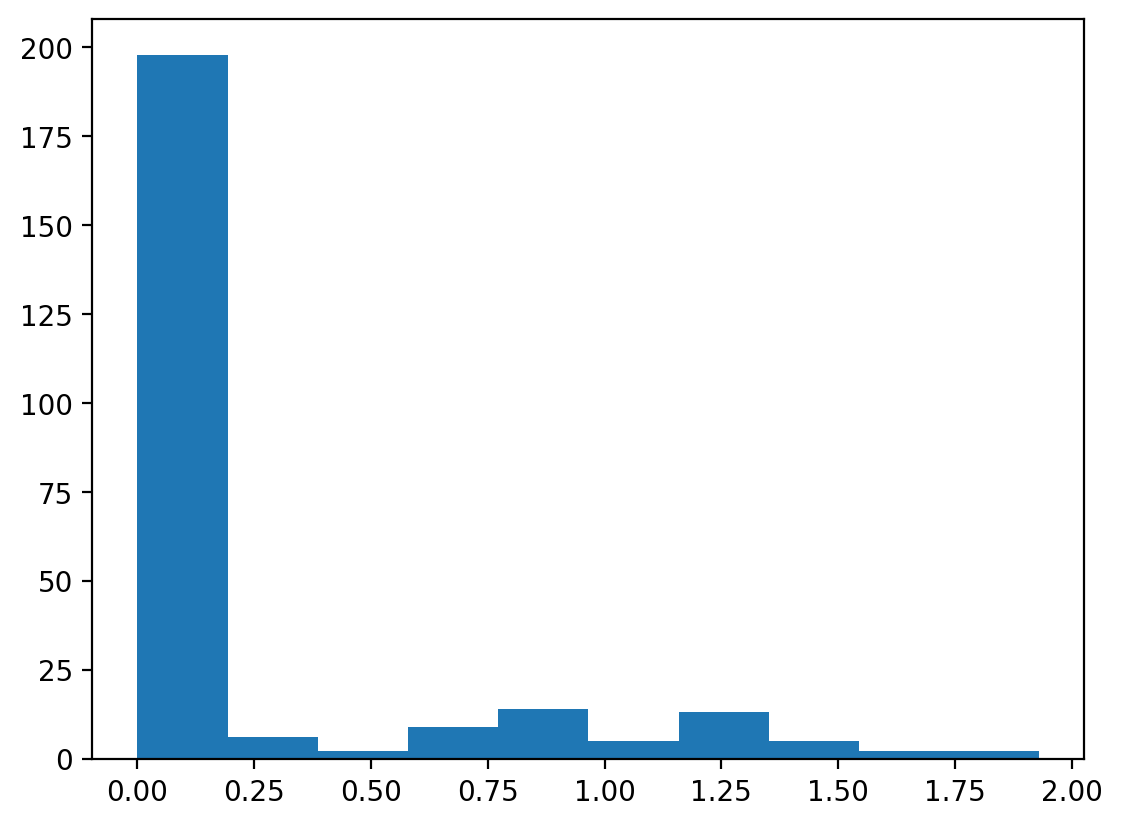

In [80]:
plt.hist(f_imgs[128].flatten())

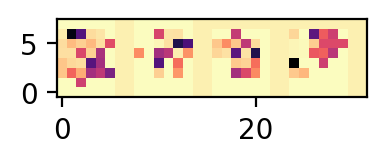

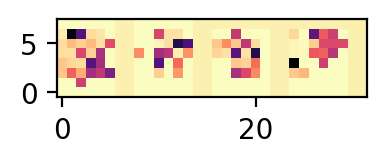

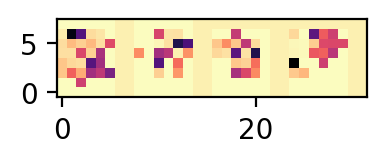

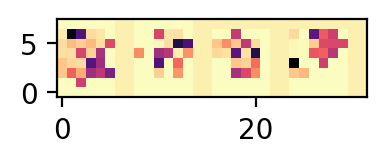

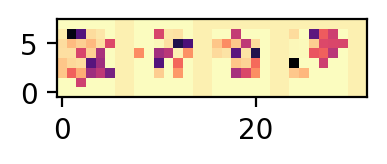

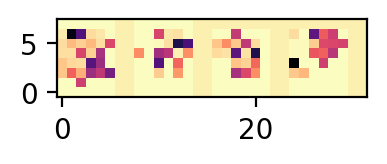

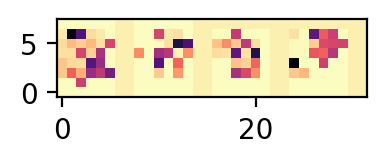

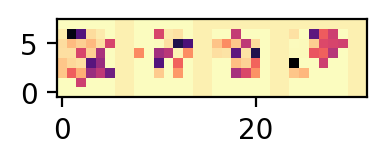

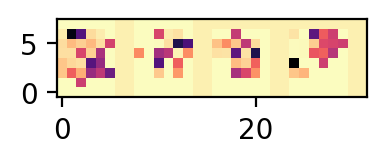

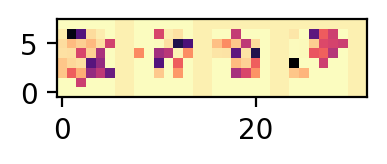

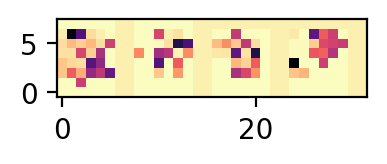

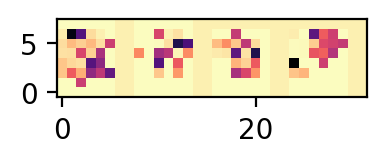

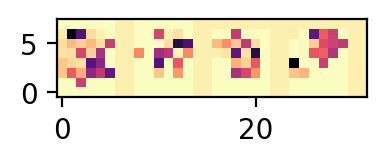

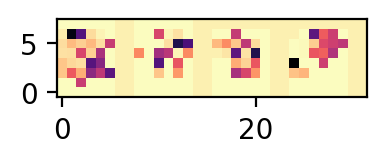

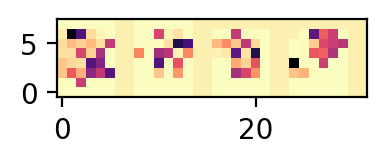

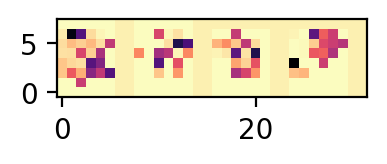

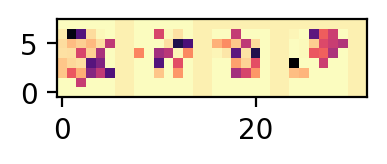

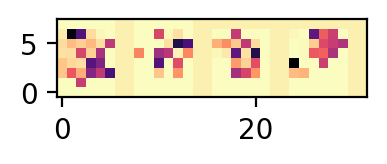

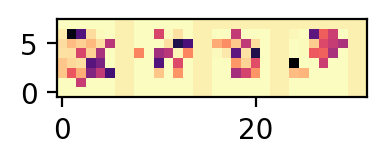

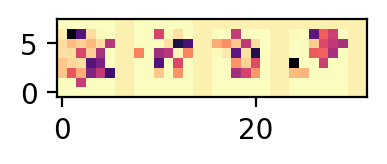

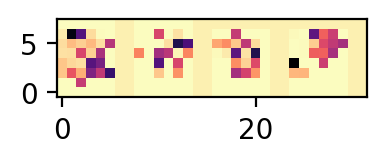

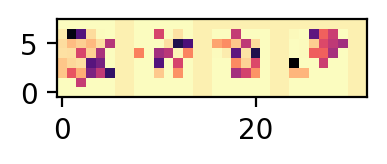

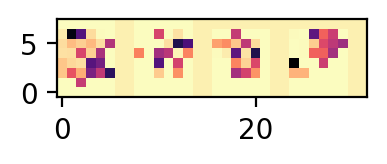

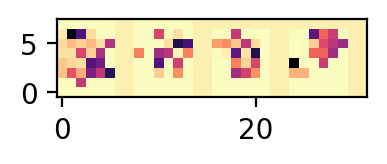

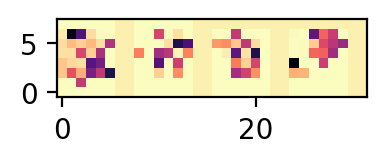

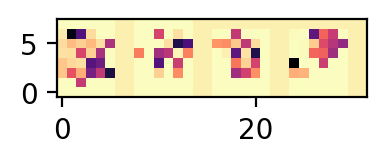

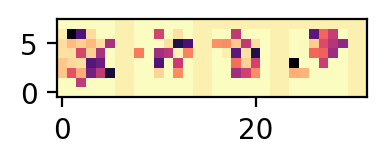

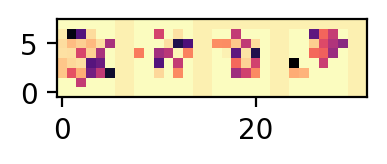

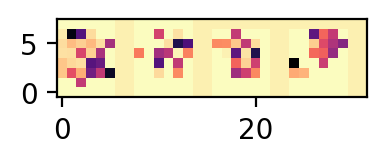

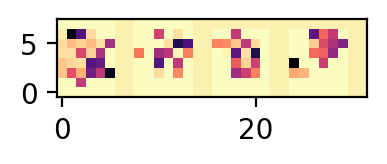

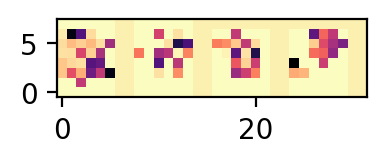

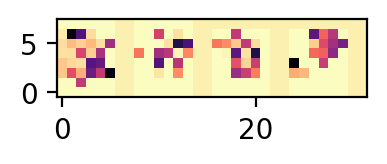

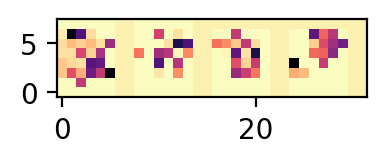

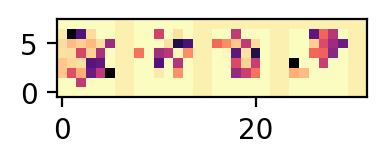

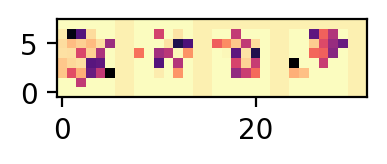

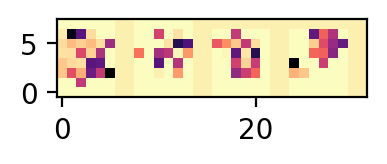

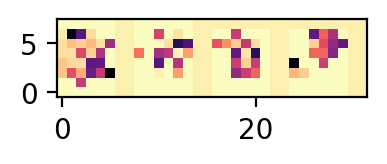

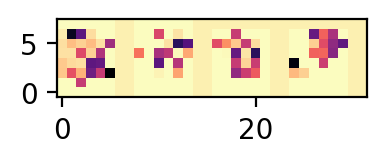

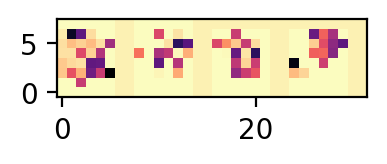

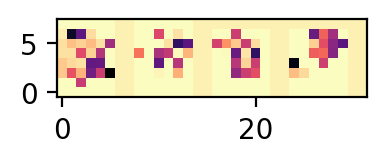

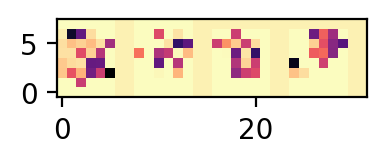

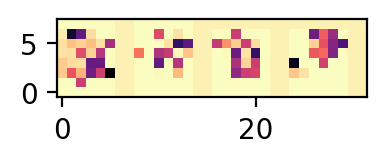

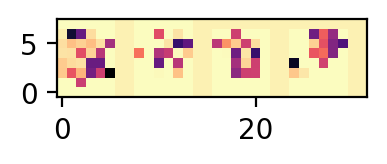

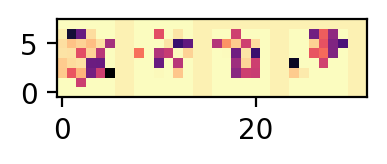

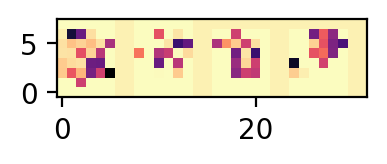

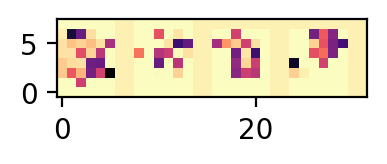

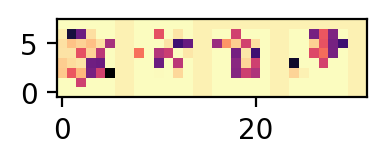

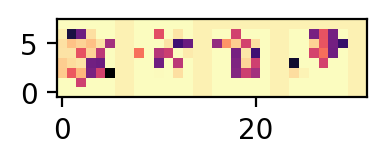

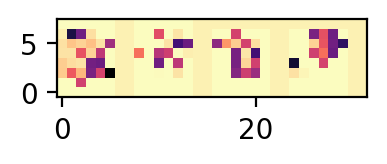

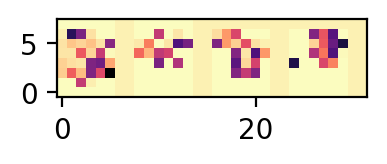

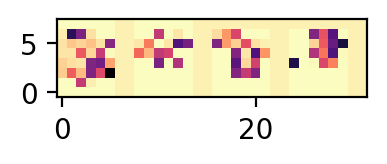

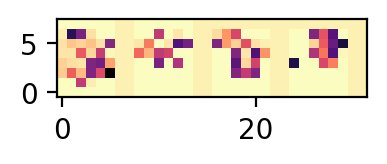

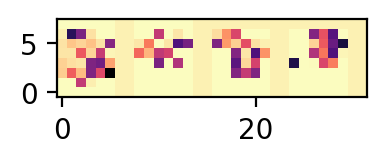

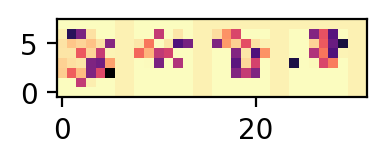

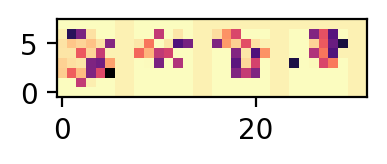

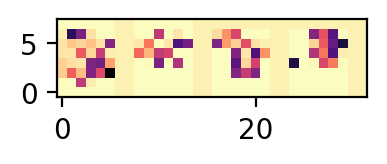

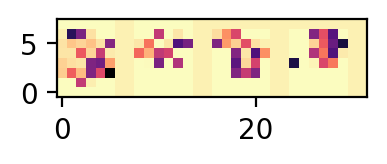

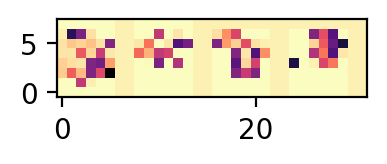

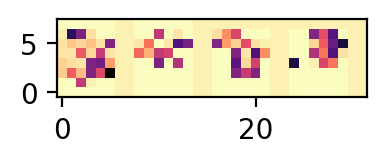

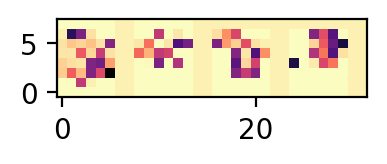

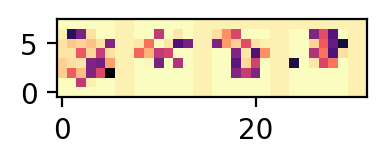

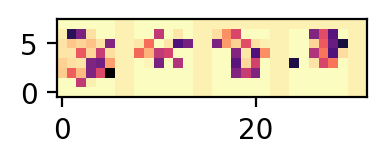

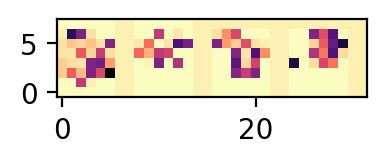

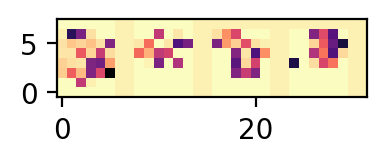

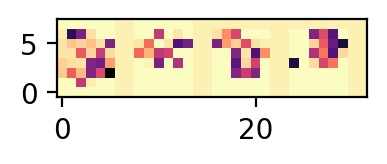

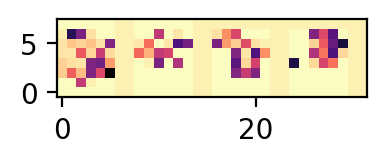

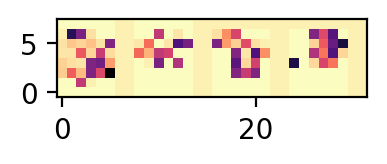

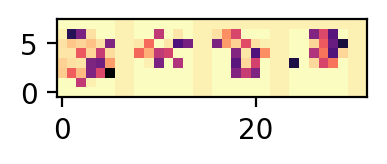

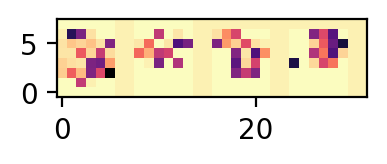

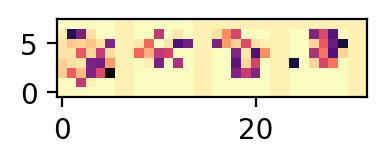

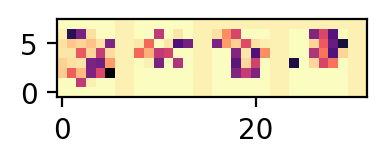

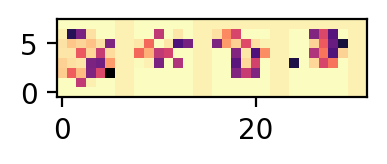

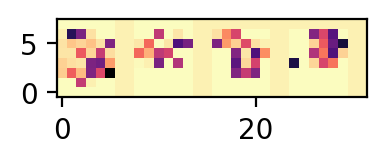

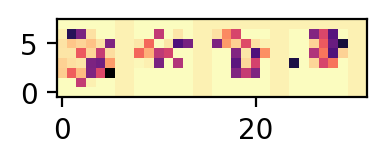

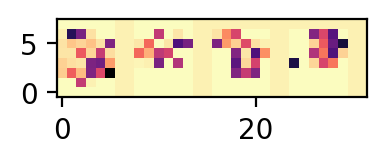

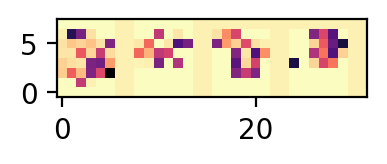

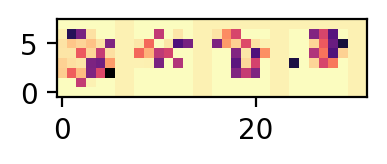

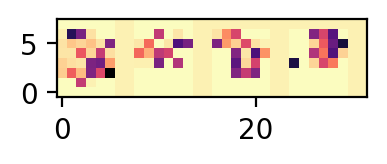

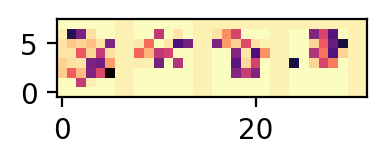

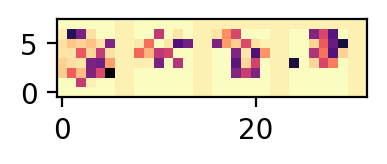

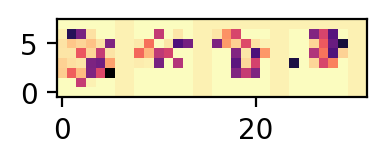

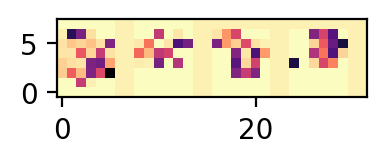

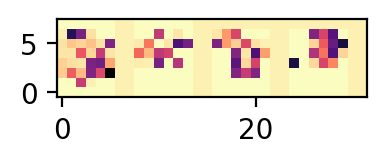

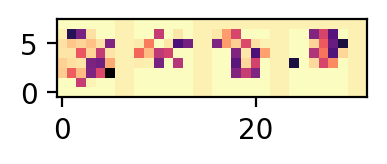

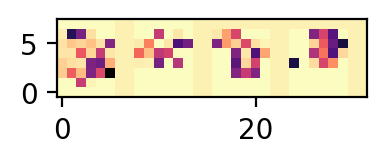

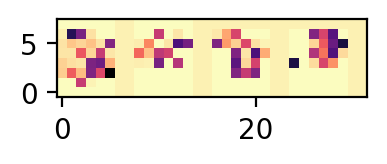

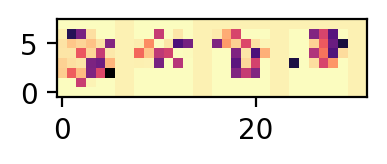

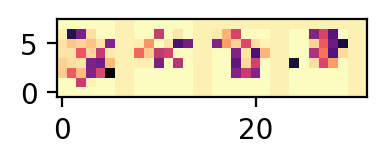

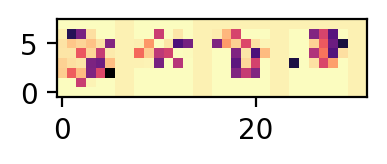

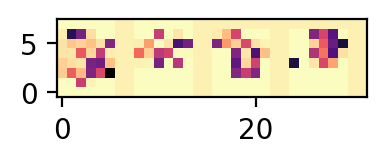

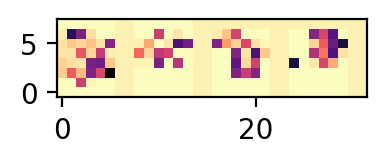

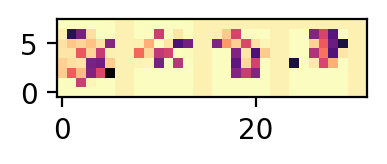

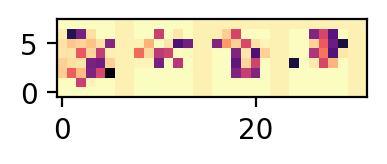

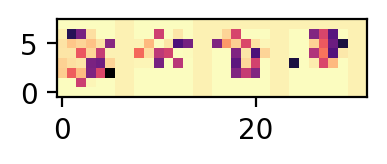

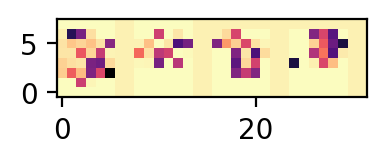

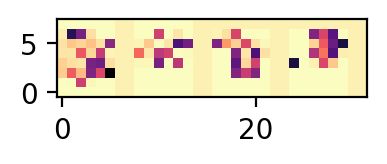

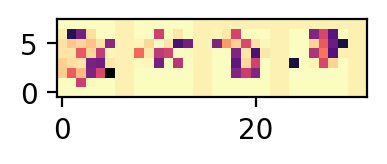

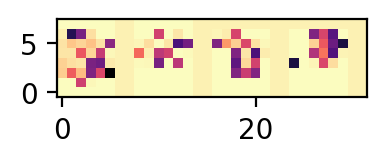

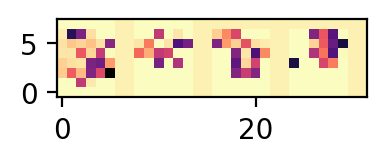

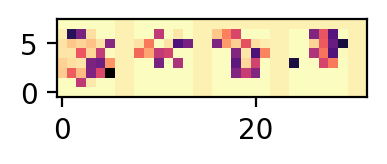

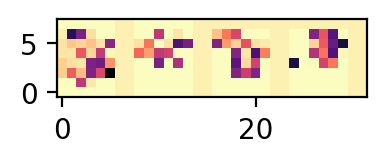

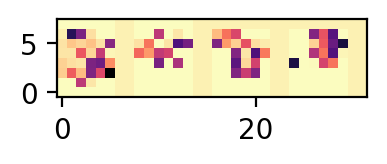

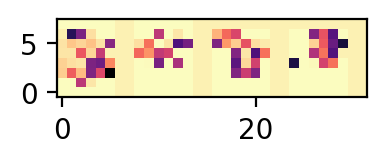

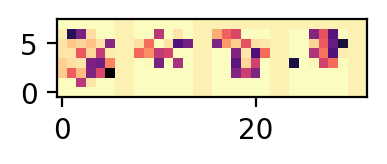

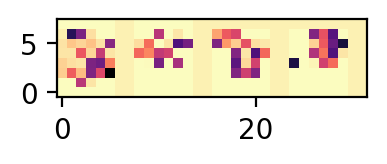

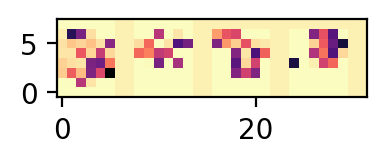

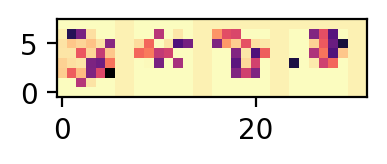

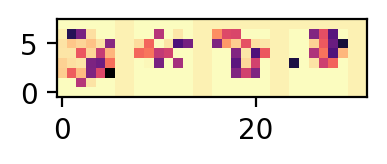

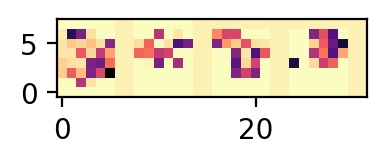

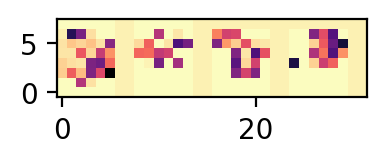

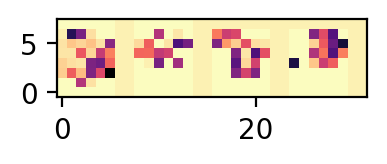

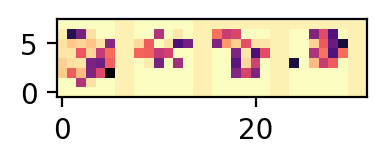

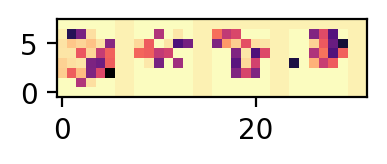

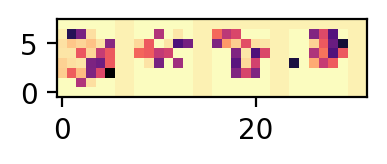

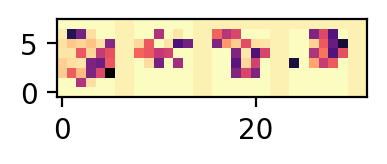

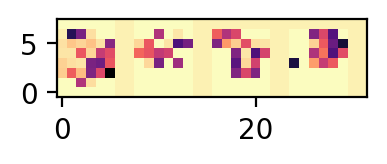

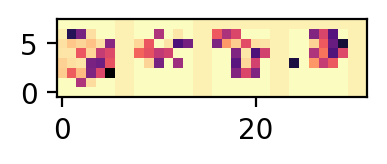

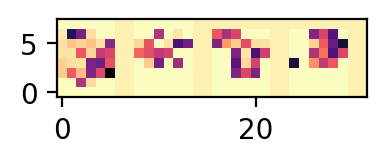

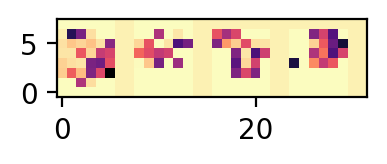

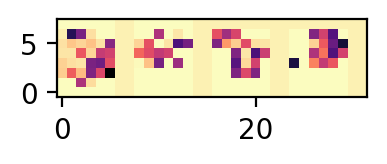

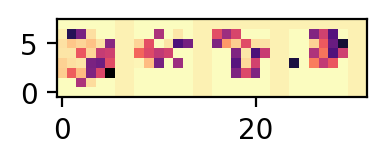

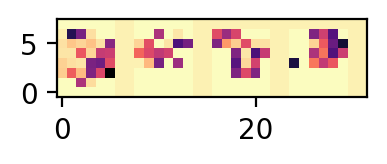

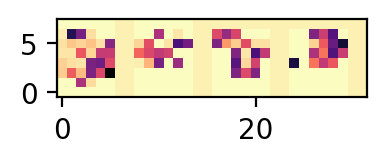

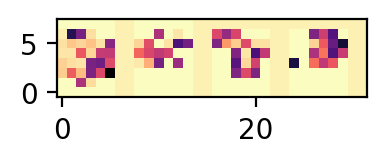

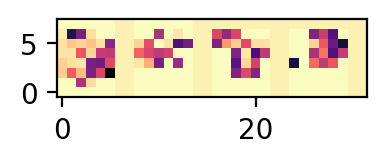

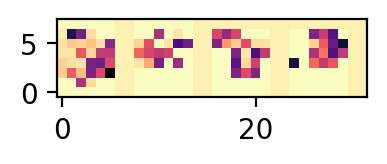

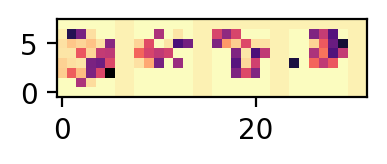

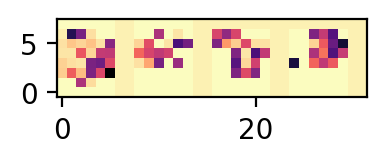

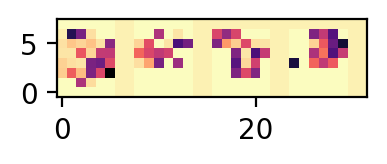

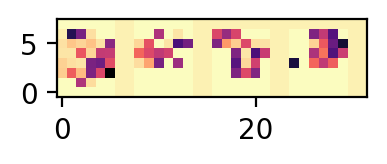

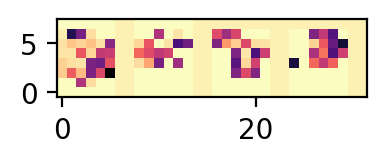

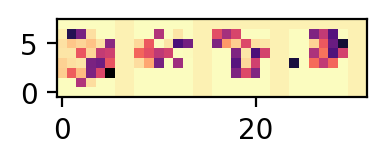

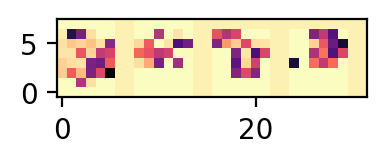

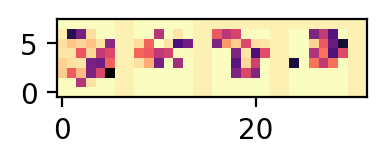

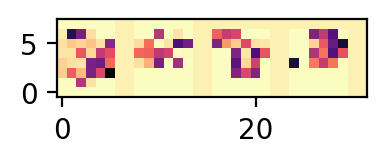

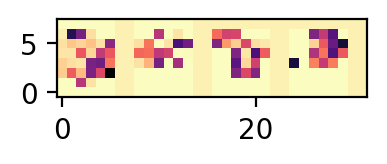

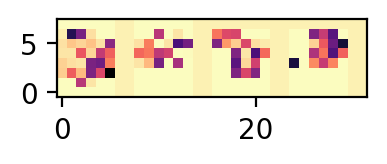

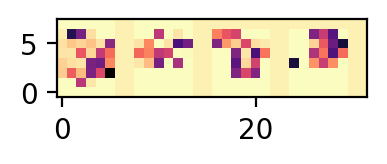

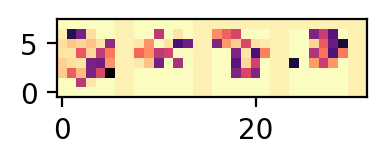

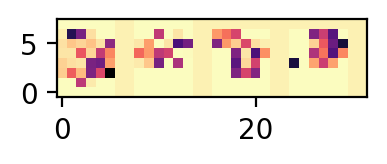

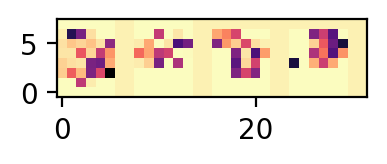

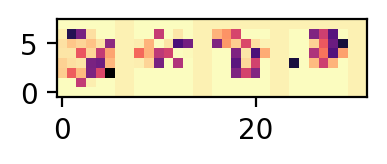

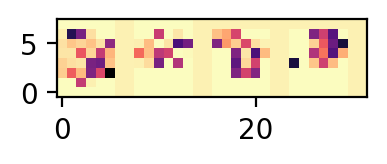

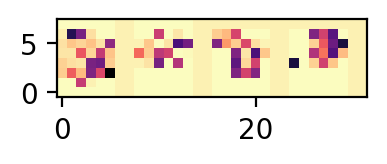

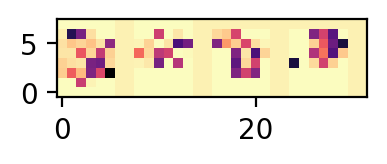

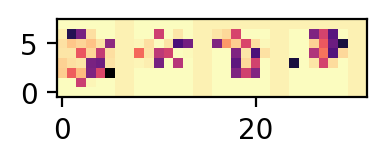

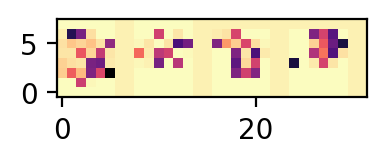

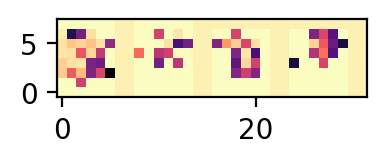

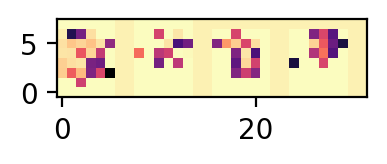

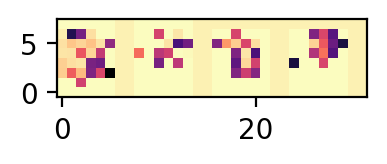

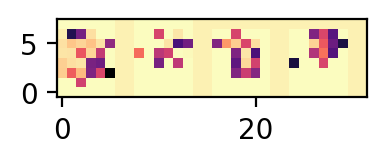

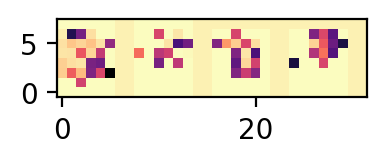

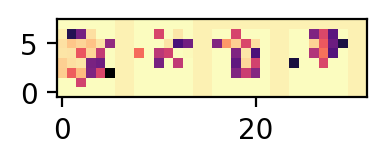

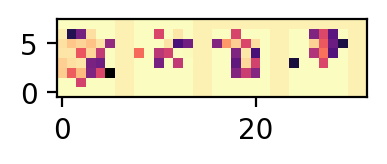

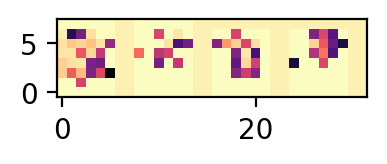

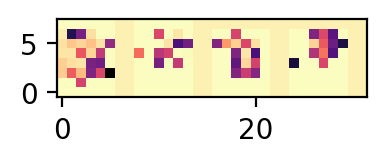

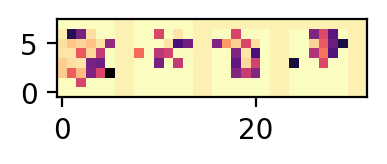

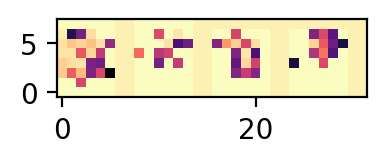

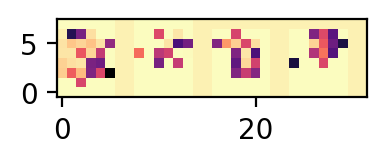

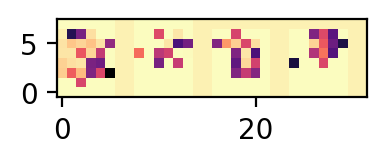

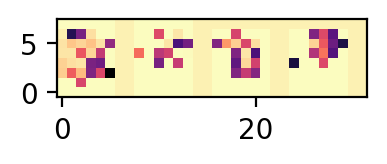

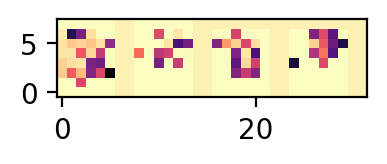

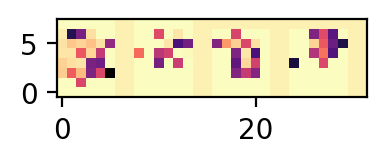

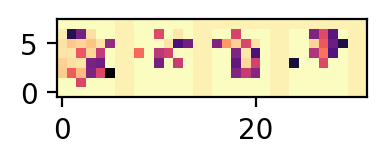

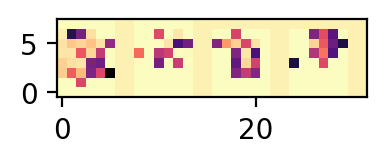

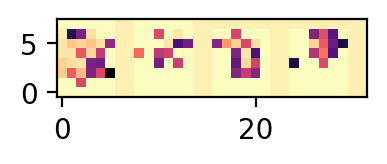

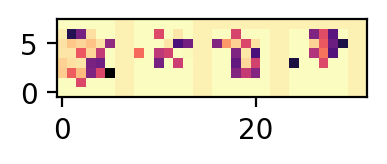

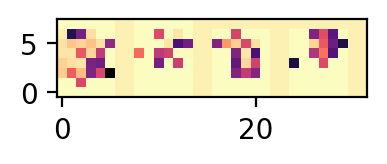

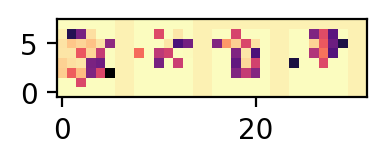

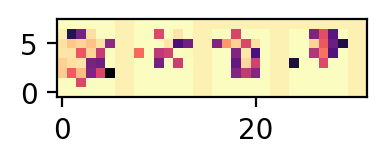

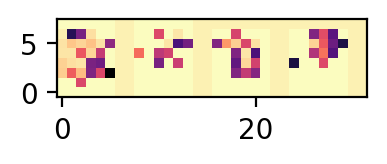

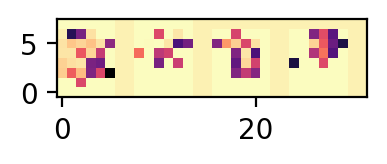

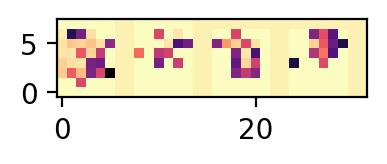

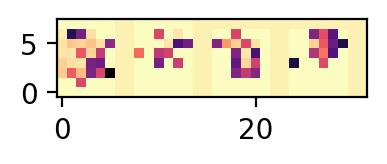

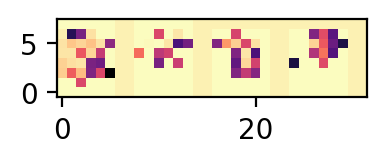

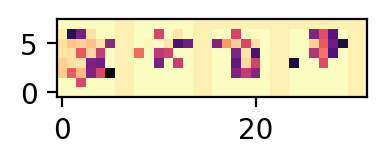

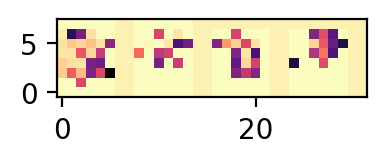

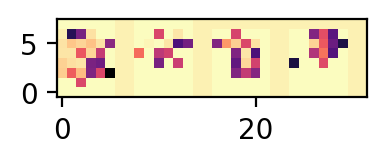

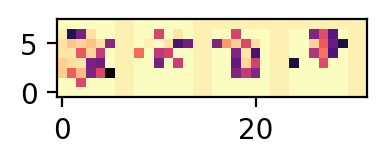

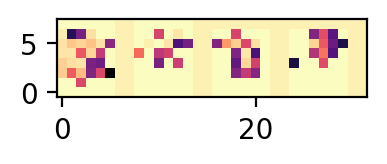

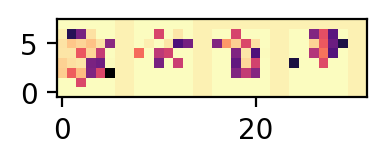

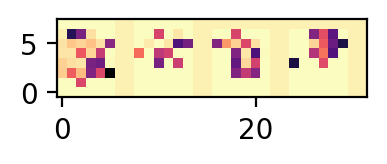

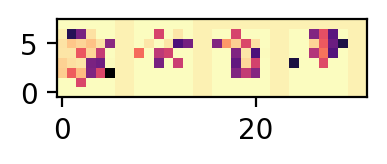

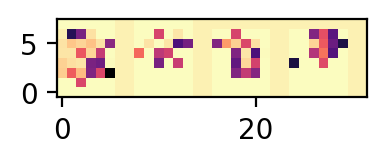

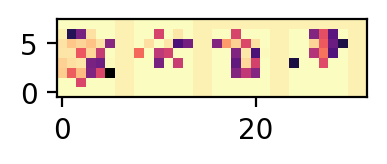

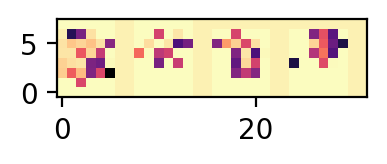

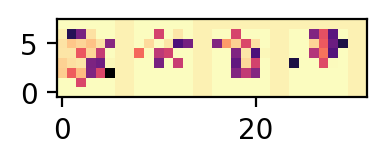

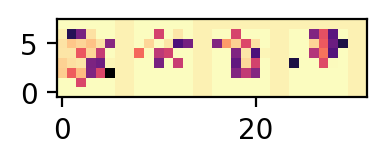

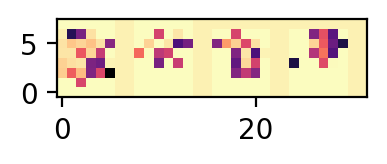

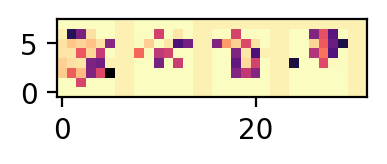

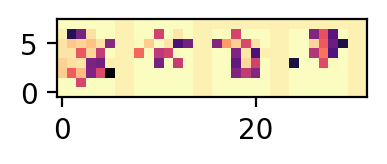

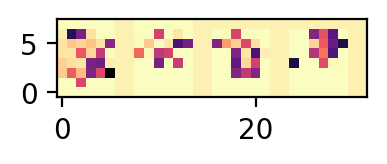

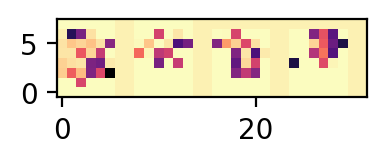

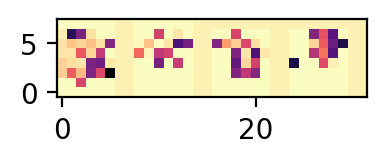

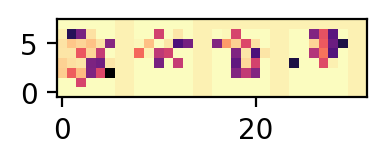

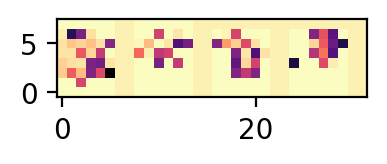

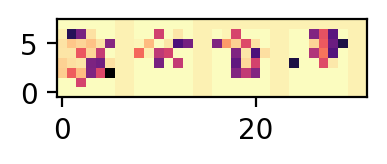

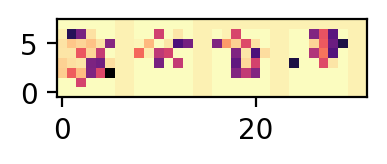

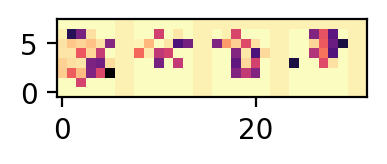

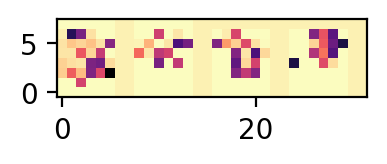

In [81]:
for i in range(200):
    plt.figure(figsize=(2, 1))
    plt.imshow(f_imgs[i], cmap='magma_r', origin='lower')
    plt.show()

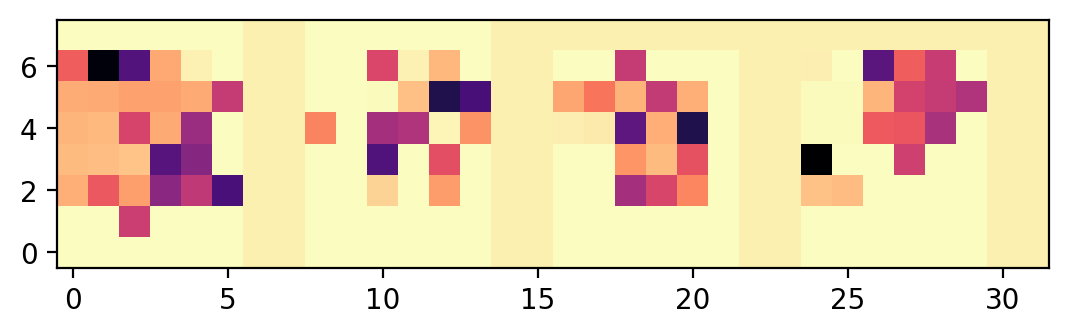

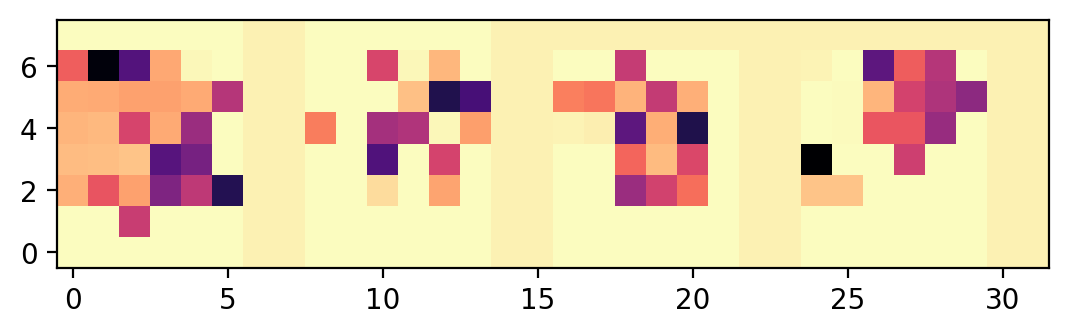

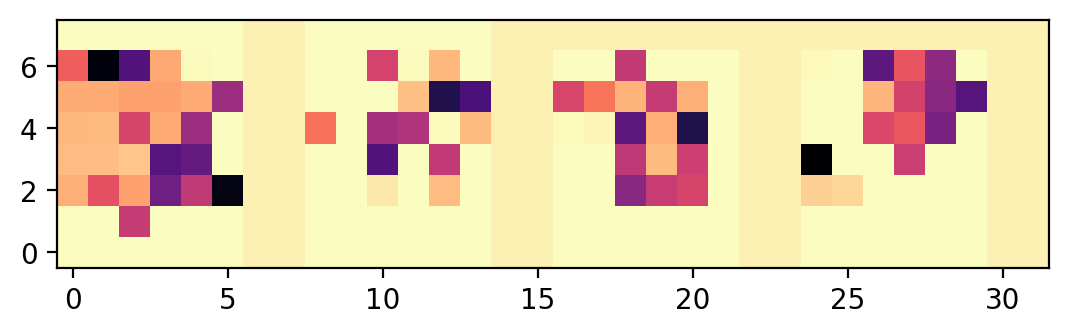

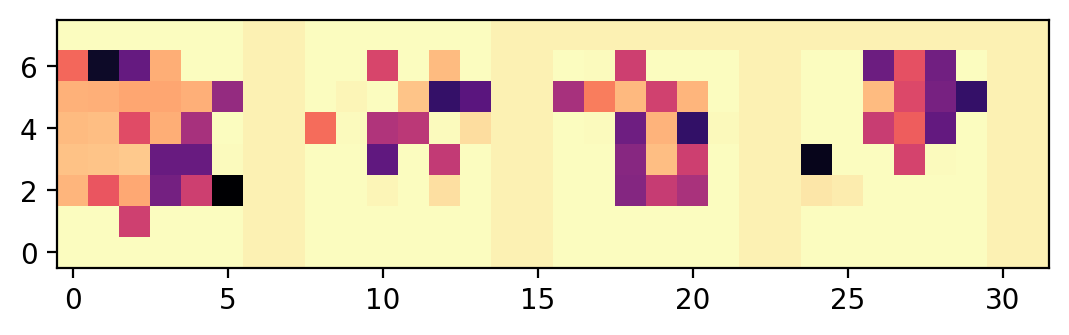

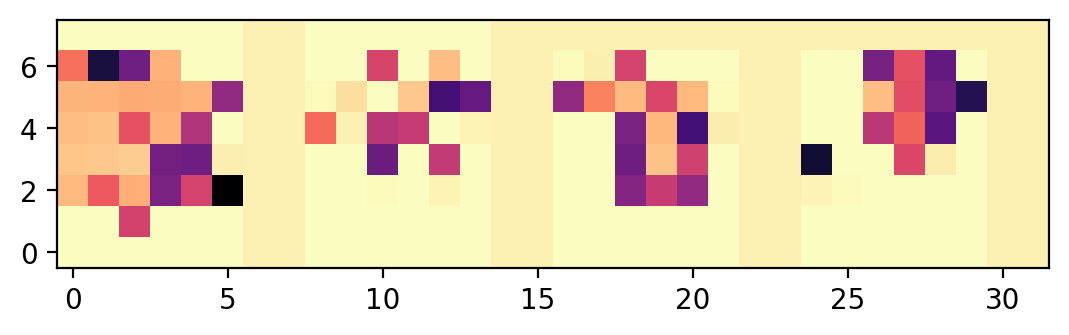

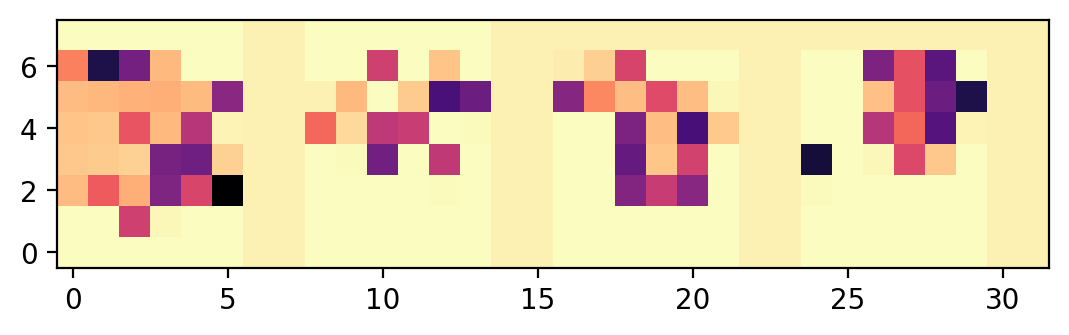

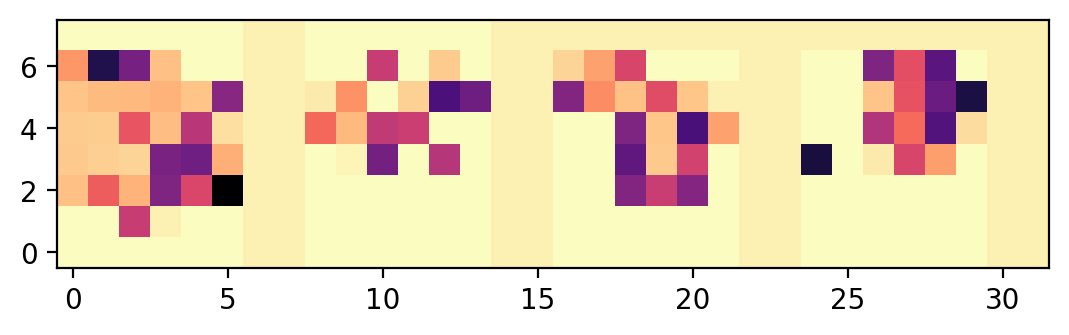

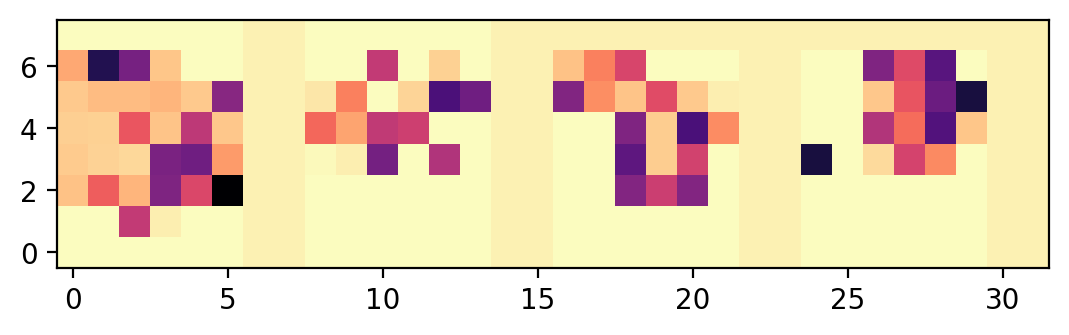

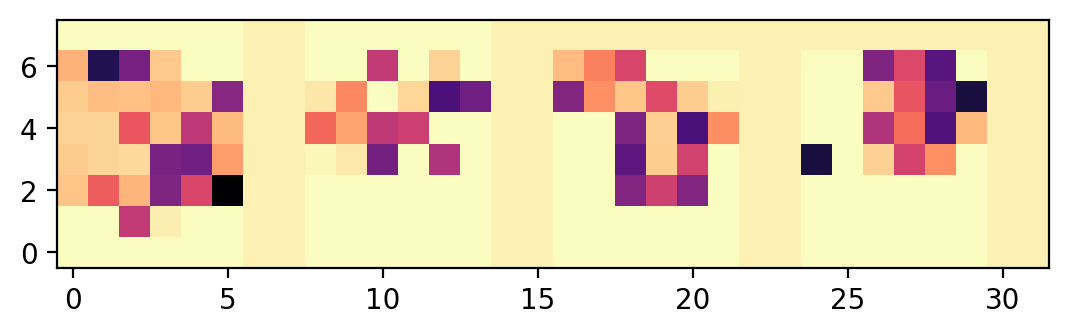

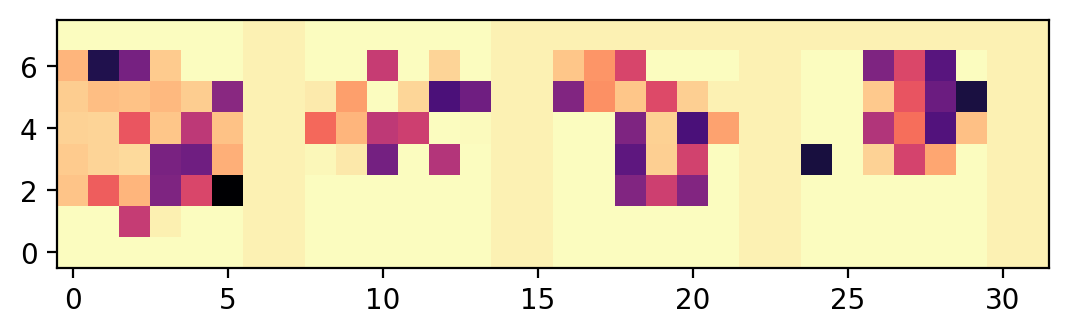

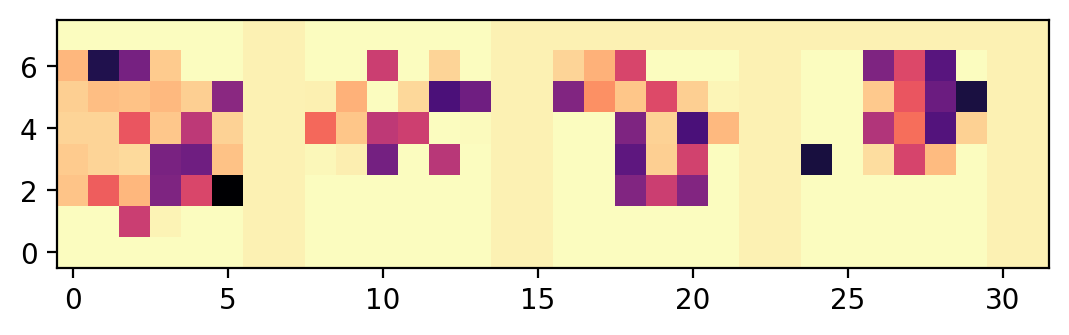

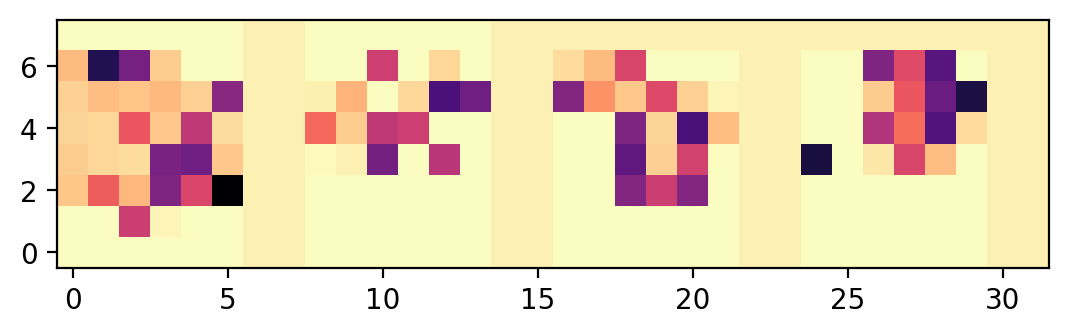

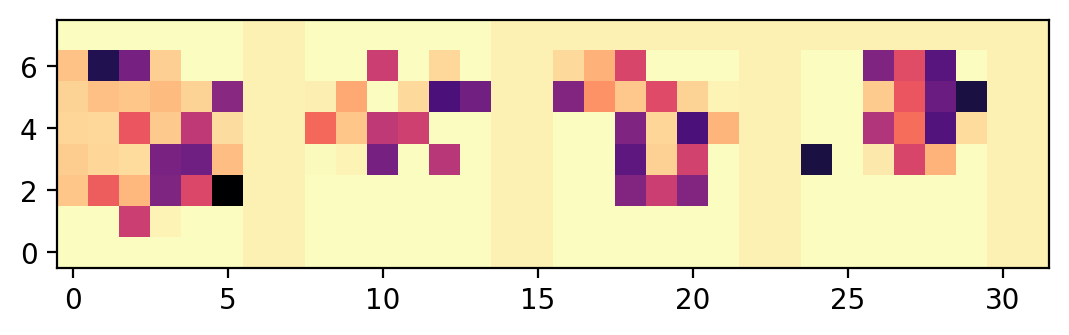

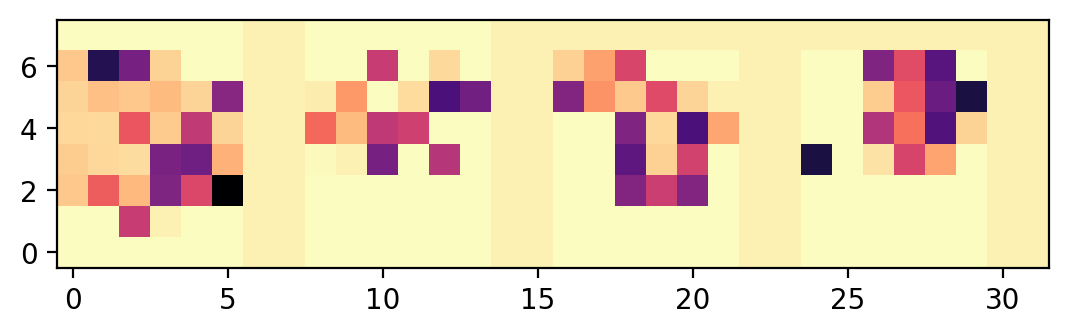

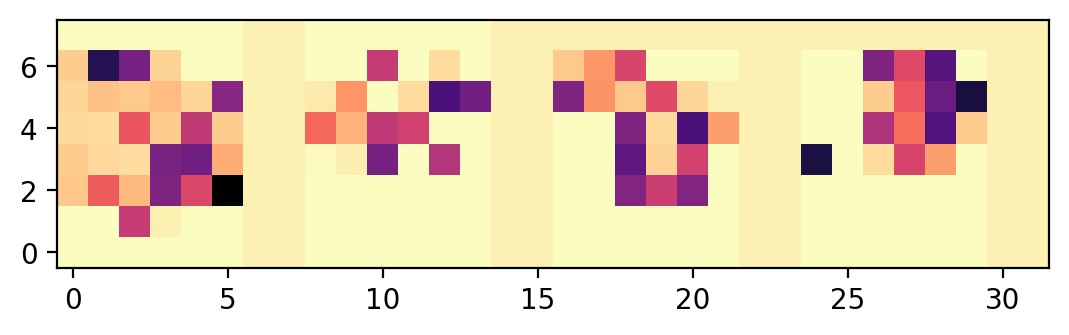

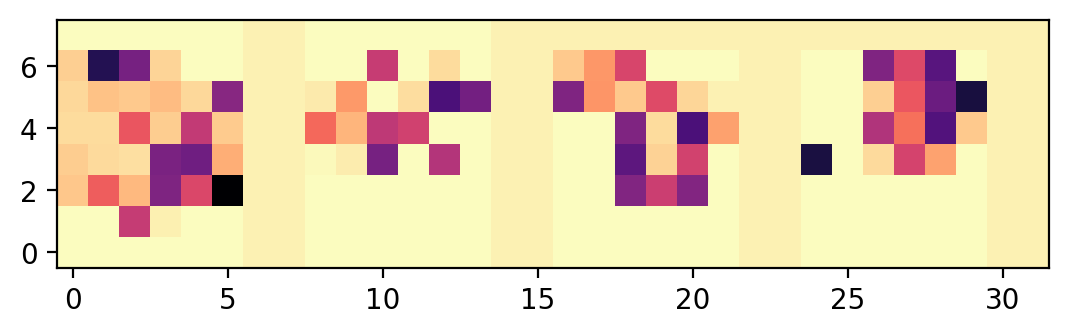

In [82]:
for i in range(pred_G_imgs.shape[0]):
    plt.imshow(pred_G_imgs[i], cmap='magma_r', origin='lower')
    plt.show()